<a href="https://colab.research.google.com/github/naathycc/Estudos-para-projeto-trainee-de-dados/blob/main/04_quarta_semana/analisando_e_tratando_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Análise e tratamento de dados feito com um dataset de custos médicos**

In [78]:
# coletando os dados:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
custos_medicos = pd.read_csv(url)

In [79]:
# Primeiras linhas da tabela
custos_medicos.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
print(f"Média: {custos_medicos['charges'].mean():.2f}")
print(f"Mediana: {custos_medicos['charges'].median():.2f}")
print("Moda:")
print(custos_medicos['charges'].mode())
# Quando usar cada um?
# Média: quando os dados estão bem distribuídos.
# Mediana: muitos outliers ou distribuição muito desigual.
# Moda: quando queremos saber o valor mais comum.

Média: 13270.42
Mediana: 9382.03
Moda:
0    1639.5631
Name: charges, dtype: float64


In [81]:
print(f"Variância: {custos_medicos['charges'].var():.2f}") #variância: quanto os dados estão espalhados em relação á média.
print(f"Desvio padrão: {custos_medicos['charges'].std():.2f}") #desvio padrão:

Variância: 146652372.15
Desvio padrão: 12110.01


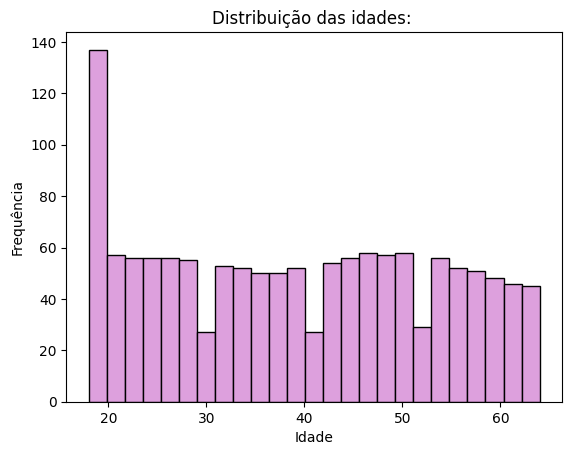

In [82]:
# Histograma com as idades:
plt.hist(custos_medicos['age'], bins=25, color='plum', edgecolor='black')
plt.title("Distribuição das idades: ")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()
# Importância desse gráfico: ver onde os dados estão concentrados,
# entender o formato de distribuição,
# identificar lacunas ou picos incomuns,
# identificar outliers.

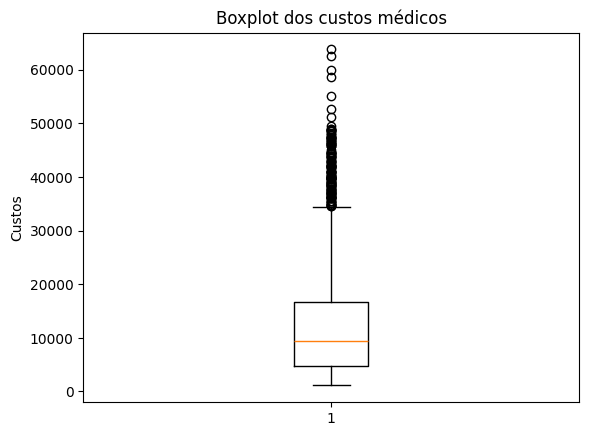

In [83]:
#boxplot dos custos médicos:
plt.boxplot(custos_medicos['charges'])
plt.title("Boxplot dos custos médicos")
plt.ylabel("Custos")
plt.show()
# importante para q1, q2/mediana, q3,
# e valores que são outliers na amostra.

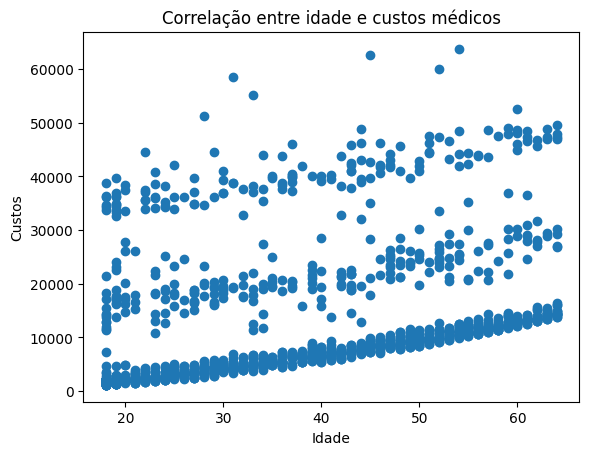

Correlação: 0.30


In [84]:
# scatterplot: gráfico que mostra a relação entre duas variaveis numéricas.
plt.scatter(custos_medicos['age'],
            custos_medicos['charges'])
plt.title("Correlação entre idade e custos médicos")
plt.xlabel("Idade")
plt.ylabel("Custos")
plt.show()
# Esse gráfico de correlação parece ter uma correlaçao positiva entre
# idade e custos médicos, já que indivíduos mais velhos possuem maior
# gasto comparando com os mais jovens, porém a relação não é muito forte,
# pois existem pessoas da mesma faixa etária com gastos bem diferentes,
# além de que pessoas mais jovens podem gastar mais do que algumas
# pessoas mais velhas. O que pode indicar que há outras variáveis
# interferindo nos custos médicos.
# Mostrando a correlação matematicamente:
correlacao = custos_medicos['age'].corr(custos_medicos['charges'])
print(f"Correlação: {correlacao:.2f}")
# O valor (0.30) indica que há uma fraca correlação entre idade e custos médicos.

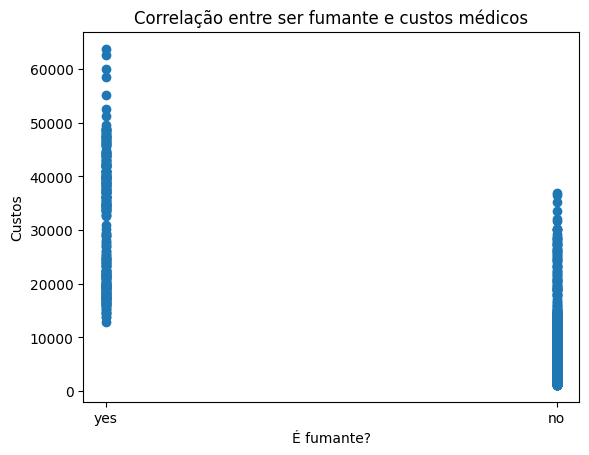

Correlação: 0.79


In [85]:
# Investigando outra variável: se é fumante e os custos médicos.
plt.scatter(custos_medicos['smoker'],
            custos_medicos['charges'])
plt.title("Correlação entre ser fumante e custos médicos")
plt.xlabel("É fumante?")
plt.ylabel("Custos")
plt.show()
# Apresenta uma correlação bem maior do que da idade com os custos
# principalmente por causa do grande aumento dos custos médicos
# quando a pessoa é fumante. Assim, fumar aumenta consideravelmente
# os custos médicos.

# Investigando a correlação matematicamente:
# Foi necessário alterar a variável utilizada na análise de correlação,
# pois a coluna 'smoker' possui valores categóricos ('yes' e 'no').
# Como o cálculo da correlação requer variáveis numéricas, optou-se
# por analisar a relação entre idade e custos médicos.
custos_medicos['smoker_num'] = custos_medicos['smoker'].map({
    'no': 0,
    'yes': 1
})

correlacao = custos_medicos['smoker_num'].corr(
    custos_medicos['charges']
)

print(f"Correlação: {correlacao:.2f}")
# A função de correlação mostrou que realmente a relação é bem forte.

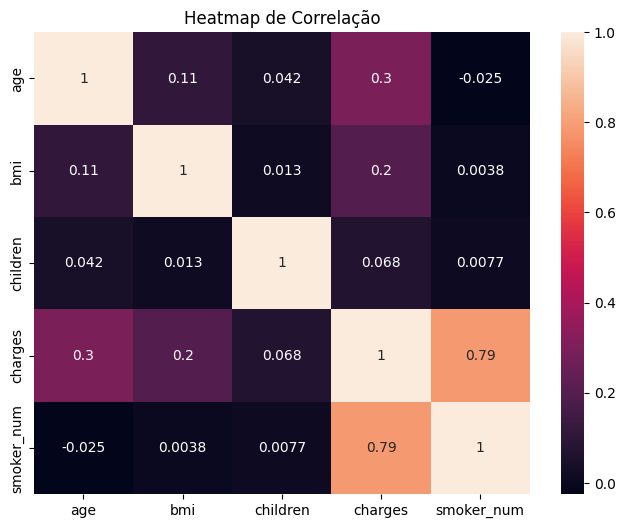

In [86]:
# Heatmap: mapa de calor que mostra a correlação entre variáveis numéricas.
# Serve para mostrar quais variáveis estão mais relacionadas.
plt.figure(figsize=(8,6))

sns.heatmap(
    custos_medicos.corr(numeric_only=True),
    annot=True
)

plt.title("Heatmap de Correlação")
plt.show()
# O heatmap demonstra que a maior correlação observada é entre o hábito
# de fumar e os custos médicos, apresentando uma correlação forte (0,79).
# Em seguida, observa-se uma correlação positiva entre idade e custos
# médicos (0,30), indicando que indivíduos mais velhos tendem a apresentar
# maiores gastos com saúde, embora essa relação seja significativamente
# mais fraca do que a observada para fumantes.
# O IMC também apresenta correlação positiva com os custos médicos (0,20),
# porém de intensidade fraca. Já o número de filhos apresenta correlação
# muito baixa (0,068), mostrando que há pouca influência sobre os custos médicos.
# Dessa forma, entre as variáveis analisadas, o hábito de fumar é o fator
# que apresenta a associação mais forte com os custos médicos.


In [87]:
custos_medicos = custos_medicos.drop('smoker_num', axis=1)

**Tratando outliers:**

In [88]:
# Com quartis:
q1 = custos_medicos['charges'].quantile(0.25)
q3 = custos_medicos['charges'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = custos_medicos[(custos_medicos['charges'] < lim_inf) | (custos_medicos['charges'] > lim_sup)]
print(f"Total de outliers: {len(outliers)}")
outliers


Total de outliers: 139


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [89]:
# Com z-score:
from scipy.stats import zscore
import numpy as np

z_scores = zscore(custos_medicos['charges']) # calcula o z-score de cada custo médico.
outliers_z = custos_medicos[np.abs(z_scores) > 3] # transforma todos os valores em positivos
# e seleciona apenas observações que são maiores que o z-score em 3.
print(f"Total de outliers com Z-score > 3: {len(outliers_z)}")

outliers_z

Total de outliers com Z-score > 3: 7


,age,sex,bmi,children,smoker,region,charges
34,28,male,36.400,1,yes,southwest,51194.55914
543,54,female,47.410,0,yes,southeast,63770.42801
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
1230,52,male,34.485,3,yes,northwest,60021.39897
1300,45,male,30.360,0,yes,southeast,62592.87309


**Como tratar outliers?**

1. Excluir (quando são erros).
2. Substituir (por média, mediana, limite, etc).

In [90]:
# Observando os maiores outliers:
outliers.sort_values('charges', ascending=False).head(15)

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
34,28,male,36.400,1,yes,southwest,51194.55914
1241,64,male,36.960,2,yes,southeast,49577.66240
1062,59,male,41.140,1,yes,southeast,48970.24760
488,44,female,38.060,0,yes,southeast,48885.13561


In [91]:
# Comparando fumantes e não fumantes nos outliers:
outliers['smoker'].value_counts()

,count
smoker,
yes,136
no,3


In [92]:
# Analisando outliers com IMC:
outliers['bmi'].describe()

,bmi
count,139.000000
mean,35.564604
std,4.434917
min,22.895000
25%,32.667500
50%,35.200000
75%,37.660000
max,52.580000


Conclusão dos outliers: Foram identificados diversos outliers no conjunto de dados, principalmente relacionados aos custos médicos. Após a análise, não foram encontrados indícios de erros de registro ou valores impossíveis que justificassem sua remoção. Observei que grande parte desses valores elevados está associada a indivíduos fumantes e com IMC acima do recomendado, fatores que podem contribuir bastante para o aumento dos gastos com saúde. Dessa forma, escolhi manter os outliers no conjunto de dados, pois eles representam observações reais e relevantes para a análise.

**Valores ausentes**

Por que acontecem?
*   Problemas técnicos: falha no sistema ou coleta incompleta.
*   Dados não aplicáveis.
*   Erros humanos.

In [93]:
# Identificando valores ausentes:
custos_medicos.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Como tratar valores ausentes? **

1. Remover linhas ou colunas

In [94]:
custos_medicos_dropped = custos_medicos.dropna()
custos_medicos_dropped

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


2. Preencher com média, mediana ou valor fixo

In [95]:
custos_medicos_mean = custos_medicos.copy() # criação de uma copia do dataframe original
custos_medicos_mean['charges'] = custos_medicos_mean['charges'].fillna(custos_medicos_mean['charges'].mean()) # subs os valores originais ausentes da tabela 'charges pela média.
custos_medicos_mean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Duplicatas, erros e inconsistências**

In [96]:
# Detectando duplicatas:
custos_medicos[custos_medicos.duplicated()]
# Detectada uma duplicata, removendo:
custos_medicos_sem_dup = custos_medicos.drop_duplicates()
print(custos_medicos_sem_dup.duplicated().sum())

0


**Fazendo outros ajustes**

In [97]:
custos_medicos = custos_medicos.rename(columns={
    'age': 'idade',
    'sex' : 'gênero',
    'bmi' : 'IMC',
    'children' : 'filhos',
    'smoker' : 'fumante',
    'region' : 'região',
    'charges' : 'custos',
})



In [104]:
custos_medicos['gênero'] = custos_medicos['gênero'].replace({
    'male' : 'masculino',
    'female' : 'feminino'
})

custos_medicos['fumante'] = custos_medicos['fumante'].replace({
    'yes' : 'sim',
    'no' : 'não'
})

custos_medicos['região'] = custos_medicos['região'].replace({
    'southwest': 'sudoeste',
    'southeast': 'sudeste',
    'northwest': 'noroeste',
    'northeast': 'nordeste'
})

In [105]:
print(custos_medicos.head())

   idade     gênero     IMC  filhos fumante    região       custos
0     19   feminino  27.900       0     sim  sudoeste  16884.92400
1     18  masculino  33.770       1     não   sudeste   1725.55230
2     28  masculino  33.000       3     não   sudeste   4449.46200
3     33  masculino  22.705       0     não  noroeste  21984.47061
4     32  masculino  28.880       0     não  noroeste   3866.85520


In [106]:
# conferindo os tipos de dados:
custos_medicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   idade    1338 non-null   int64  
 1   gênero   1338 non-null   object 
 2   IMC      1338 non-null   float64
 3   filhos   1338 non-null   int64  
 4   fumante  1338 non-null   object 
 5   região   1338 non-null   object 
 6   custos   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [107]:
# Verificando categorias inesperadas
print(custos_medicos['fumante'].unique())
print(custos_medicos['gênero'].unique())
print(custos_medicos['região'].unique())

['sim' 'não']
['feminino' 'masculino']
['sudoeste' 'sudeste' 'noroeste' 'nordeste']


**Conclusão:**
A análise exploratória dos dados permitiu identificar os principais fatores que fazem com que os gastos com saúde sejam maiores. Os resultados mostraram que o hábito de fumar apresenta a relação mais forte com os gastos em saúde, apresentando correlação de 0,79 com a variável de custos. Além disso, idade e IMC também demonstraram associação positiva com os custos médicos, mas de forma bem menos intensa.

Na limpeza dos dados, não foram encontrados valores ausentes e apenas um registro duplicado foi identificado e removido. Os outliers detectados foram buscados e foi verificado que estavam relacionados a indivíduos fumantes, mais velhos e com o IMC acima do recomendado.   Assim, optei por mantê-los no conjunto de dados, pois representam observações relevantes para a análise.

Por fim, conclui-se que o dataset escolhido apresenta alta qualidade nos dados, com 1 duplicada e nenhum valor faltantes, além de outliers relevantes para a análise de dados. Além disso, aprendi que a variável mais importante para os custos superiores em saúde é o indivíduo ter o hábito de fumar, assim como a idade e IMC mas com correlações bem menores quando comparados com ser fumante.
